# Plot OH lines

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import * 
import speclite.filters



In [2]:
file_path = '/Users/tliu/oh_suppression/data/ronorm.csv'

normalised_spectrum = np.loadtxt(file_path, delimiter=',')

# with open(file_path, 'r') as f:
#     for line in f:
        # print(line.strip())

In [3]:
normalised_spectrum

array([[6.13824000e-01, 1.63340119e-02],
       [6.13827000e-01, 1.63340119e-02],
       [6.13847000e-01, 4.36395979e-02],
       ...,
       [2.57866000e+00, 6.68941411e-07],
       [2.62297000e+00, 3.23693893e-08],
       [2.62401000e+00, 3.23693893e-08]], shape=(4732, 2))

In [4]:
wavelengths = normalised_spectrum[:, 0]
intensities = normalised_spectrum[:, 1]
wavelengths, intensities

(array([0.613824, 0.613827, 0.613847, ..., 2.57866 , 2.62297 , 2.62401 ],
       shape=(4732,)),
 array([1.63340119e-02, 1.63340119e-02, 4.36395979e-02, ...,
        6.68941411e-07, 3.23693893e-08, 3.23693893e-08], shape=(4732,)))

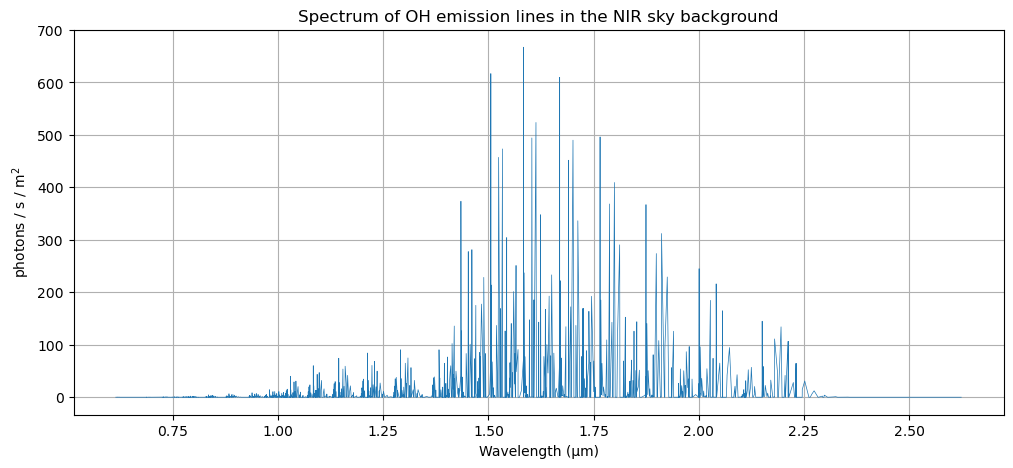

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(normalised_spectrum[:, 0], normalised_spectrum[:, 1], label="Normalised Spectrum", linewidth=0.5)
plt.xlabel("Wavelength (µm)")
plt.ylabel("photons / s / m$^2$")
plt.title("Spectrum of OH emission lines in the NIR sky background")
plt.grid()

In [6]:
# read the txt file
transmission_data = np.loadtxt('/Users/tliu/oh_suppression/data/atmostrans.txt')
wavelengths_transmission = transmission_data[:, 0]
transmission_values = transmission_data[:, 1]

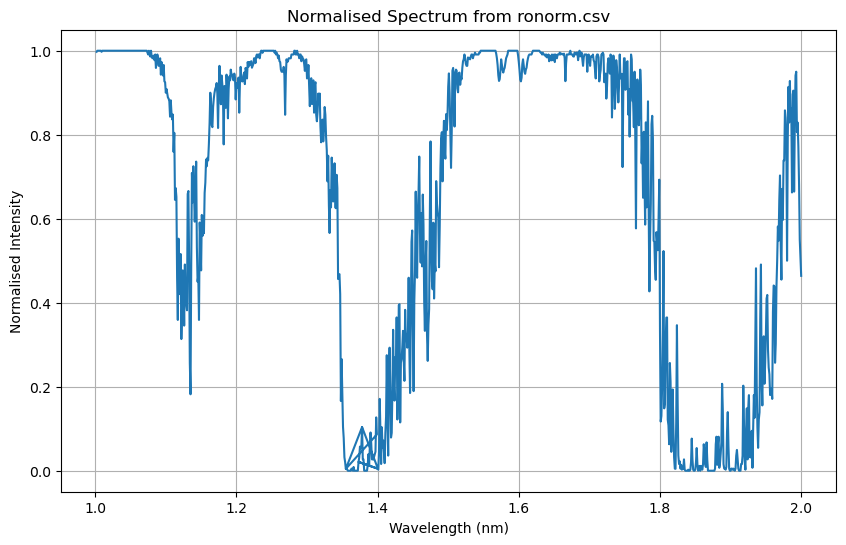

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(transmission_data[:, 0], transmission_data[:, 1], label="Normalised Spectrum")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalised Intensity")
plt.title("Normalised Spectrum from ronorm.csv")
plt.grid()

In [8]:
with open("/Users/tliu/oh_suppression/data/H.filt", "r", encoding="utf-8") as file:
    for line in file:
        print(line.strip()) 

12977 3.05e-05
12982 3.05e-05
12987 6.1e-05
12992 6.1e-05
12997 0.0001372
13002 0.0001067
13007 3.05e-05
13012 3.05e-05
13017 0
13022 0
13027 3.05e-05
13032 6.1e-05
13036 6.1e-05
13041 9.15e-05
13046 9.15e-05
13051 9.15e-05
13056 9.15e-05
13061 9.15e-05
13066 6.1e-05
13071 3.05e-05
13076 6.1e-05
13081 3.05e-05
13086 3.05e-05
13091 6.1e-05
13096 3.05e-05
13101 6.1e-05
13106 6.1e-05
13111 6.1e-05
13116 9.15e-05
13121 9.15e-05
13126 6.1e-05
13131 3.05e-05
13136 3.05e-05
13141 0
13146 3.05e-05
13151 3.05e-05
13156 0
13161 3.05e-05
13166 3.05e-05
13171 6.1e-05
13176 9.15e-05
13181 6.1e-05
13186 9.15e-05
13191 9.15e-05
13196 6.1e-05
13201 6.1e-05
13206 6.1e-05
13211 6.1e-05
13216 6.1e-05
13221 9.15e-05
13226 9.15e-05
13231 6.1e-05
13236 9.15e-05
13241 9.15e-05
13246 3.05e-05
13251 -4.58e-05
13256 -1e-07
13261 -4.58e-05
13266 3.05e-05
13271 0.0001067
13276 3.05e-05
13281 3.05e-05
13286 0
13291 3.05e-05
13296 3.05e-05
13301 3.05e-05
13306 6.1e-05
13311 3.05e-05
13316 6.1e-05
13321 0.0001067
13

In [61]:
H_filter = np.loadtxt("/Users/tliu/oh_suppression/data/H.filt", skiprows=200, max_rows=1100)
H_filter

array([[1.3975e+04, 7.6400e-05],
       [1.3980e+04, 1.0690e-04],
       [1.3985e+04, 1.5260e-04],
       ...,
       [1.9450e+04, 1.3740e-04],
       [1.9455e+04, 2.1360e-04],
       [1.9460e+04, 2.8990e-04]], shape=(1100, 2))

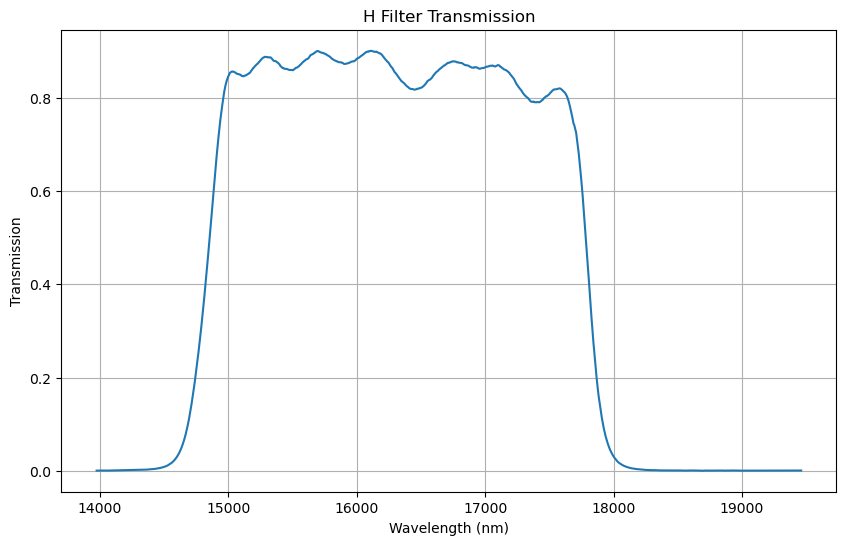

In [62]:
plt.figure(figsize=(10, 6))
plt.plot(H_filter[:,0], H_filter[:,1], label="H Filter Transmission")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Transmission")
plt.title("H Filter Transmission")
plt.grid()

In [63]:
J_filter = np.loadtxt("/Users/tliu/oh_suppression/data/J.filt", skiprows=500, max_rows=1500)
J_filter

array([[ 1.1000e+04, -3.0726e-04],
       [ 1.1002e+04,  1.2291e-04],
       [ 1.1004e+04,  4.1422e-04],
       ...,
       [ 1.3994e+04, -1.5360e-05],
       [ 1.3996e+04,  4.3009e-04],
       [ 1.3998e+04, -4.6159e-04]], shape=(1500, 2))

In [64]:
K_filter = np.loadtxt("/Users/tliu/oh_suppression/data/K.filt")
K_filter

array([[1.2977e+04, 3.0500e-05],
       [1.2982e+04, 3.0500e-05],
       [1.2987e+04, 6.1000e-05],
       ...,
       [1.9954e+04, 4.8830e-04],
       [1.9959e+04, 5.7980e-04],
       [1.9964e+04, 6.5610e-04]], shape=(1401, 2))

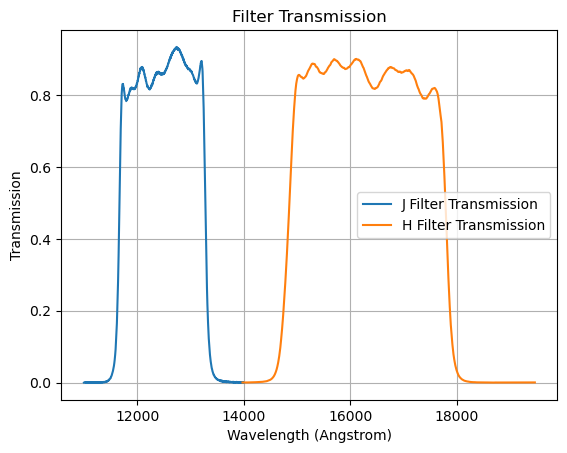

In [65]:
plt.plot(J_filter[:,0], J_filter[:,1], label="J Filter Transmission")
plt.plot(H_filter[:,0], H_filter[:,1], label="H Filter Transmission")
# plt.plot(K_filter[:,0], K_filter[:,1], label="K Filter Transmission")

plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Transmission")
plt.title("Filter Transmission")
plt.grid()
plt.legend()

In [66]:
# only keep the first 1000 values in the K filter data

K_filter_replaced = np.loadtxt("/Users/tliu/oh_suppression/data/nsfcam_k_trans.dat", skiprows=900, max_rows=1200)

K_filter_replaced

array([[1.66667e+00, 1.89948e-03],
       [1.66722e+00, 3.28302e-03],
       [1.66778e+00, 2.39801e-03],
       ...,
       [2.77316e+00, 1.64509e-04],
       [2.77469e+00, 2.44379e-04],
       [2.77624e+00, 2.08378e-04]], shape=(1200, 2))

In [67]:
K_filter_test_short = np.loadtxt("/Users/tliu/oh_suppression/data/nsfcam_ksmk_trans.dat", skiprows=1)
K_filter_test_short

array([[2.6     , 0.074768],
       [2.5922  , 0.021362],
       [2.5917  , 0.012207],
       ...,
       [1.796   , 0.012207],
       [1.7955  , 0.013733],
       [1.795   , 0.013733]], shape=(1601, 2))

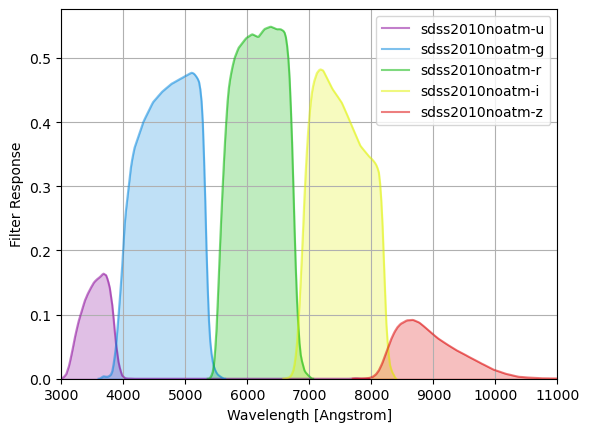

In [68]:
sdss_noatm = speclite.filters.load_filters('sdss2010noatm-*') 
speclite.filters.plot_filters(sdss_noatm, wavelength_limits=(3000, 11000))

# Display the plot
plt.show()


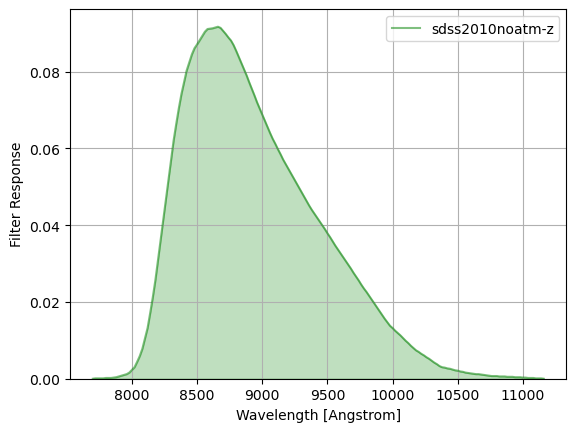

In [69]:
# Load only the z band filter
sdss_z = speclite.filters.load_filters('sdss2010noatm-z')

# Plot the single filter
speclite.filters.plot_filters(sdss_z)

# Display the plot
plt.show()

In [70]:
sdss_noatm

In [71]:
# 1. Fetch the single z-filter object from the loaded response
sdss_z_group = speclite.filters.load_filters('sdss2010noatm-z')
z_filter = sdss_z_group[0]  # Extract the individual filter object

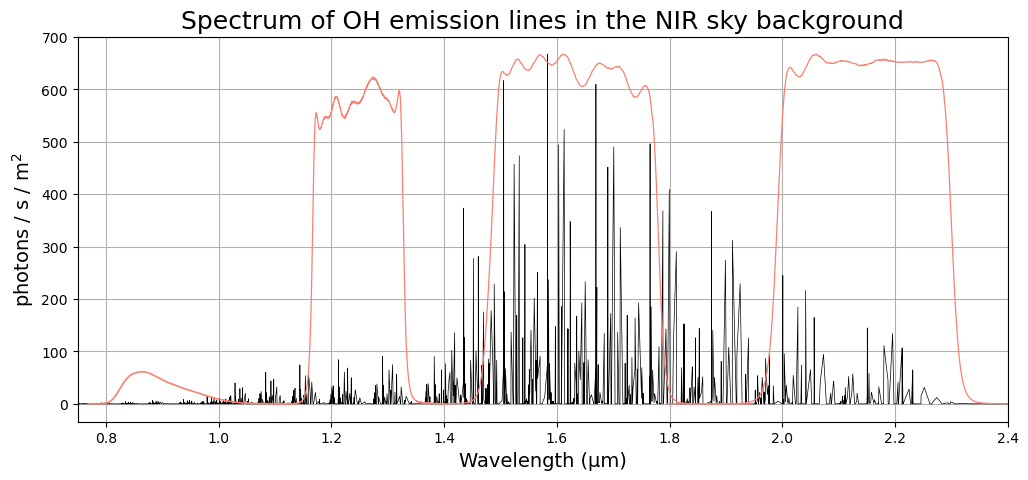

In [72]:
plt.figure(figsize=(12, 5))
plt.plot(normalised_spectrum[:, 0], normalised_spectrum[:, 1], label="Normalised Spectrum", linewidth=0.5, color='k')
plt.plot(J_filter[:,0]*1e-4, J_filter[:,1] * np.max(normalised_spectrum[:, 1]), color='salmon', linewidth=0.9)
plt.plot(H_filter[:,0]*1e-4, H_filter[:,1] * np.max(normalised_spectrum[:, 1]) / np.max(H_filter[:,1]), color='salmon', linewidth=0.9)
# plt.plot(K_filter_replaced[:,0], K_filter_replaced[:,1] * np.max(normalised_spectrum[:, 1]), label="K Filter Transmission", color='salmon', linewidth=0.9)
plt.plot(K_filter_test_short[:,0], K_filter_test_short[:,1] /  np.max(K_filter_test_short[:,1]) * np.max(normalised_spectrum[:, 1]), color='salmon', linewidth=0.9)

# 3. Scale and plot the SDSS z-filter onto the same axes
# Convert wavelengths from Angstroms to micrometers
z_wavelength_um = z_filter.wavelength * 1e-4 
# Scale response to match the peak height of your spectrum
z_response_scaled = z_filter.response * np.max(normalised_spectrum[:, 1]) 

plt.plot(z_wavelength_um, z_response_scaled, label="SDSS z Filter", color='salmon', linewidth=1.2)


plt.xlim(0.75, 2.4)
plt.xlabel("Wavelength (µm)", fontsize=14)
plt.ylabel("photons / s / m$^2$", fontsize=14)
plt.title("Spectrum of OH emission lines in the NIR sky background", fontsize=18)
plt.grid()

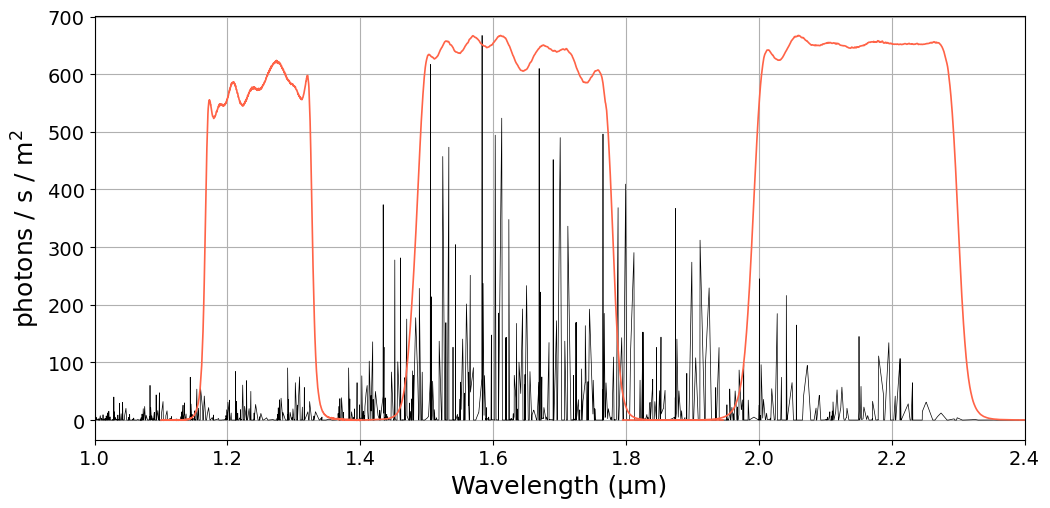

In [125]:
plt.figure(figsize=(12, 5.5))
plt.plot(normalised_spectrum[:, 0], normalised_spectrum[:, 1], label="Normalised Spectrum", linewidth=0.5, color='k')
plt.plot(J_filter[:,0]*1e-4, J_filter[:,1] * np.max(normalised_spectrum[:, 1]), color='tomato', linewidth=1.2)
plt.plot(H_filter[:,0]*1e-4, H_filter[:,1] * np.max(normalised_spectrum[:, 1]) / np.max(H_filter[:,1]), color='tomato', linewidth=1.2)
# plt.plot(K_filter_replaced[:,0], K_filter_replaced[:,1] * np.max(normalised_spectrum[:, 1]), label="K Filter Transmission", color='salmon', linewidth=0.9)
plt.plot(K_filter_test_short[:,0], K_filter_test_short[:,1] /  np.max(K_filter_test_short[:,1]) * np.max(normalised_spectrum[:, 1]), color='tomato', linewidth=1.2)

# 3. Scale and plot the SDSS z-filter onto the same axes
# Convert wavelengths from Angstroms to micrometers
z_wavelength_um = z_filter.wavelength * 1e-4 
# Scale response to match the peak height of your spectrum
z_response_scaled = z_filter.response * np.max(normalised_spectrum[:, 1]) 

# plt.plot(z_wavelength_um, z_response_scaled, label="SDSS z Filter", color='salmon', linewidth=2)


plt.xlim(1.0, 2.4)
# Axis tick font size
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Wavelength (µm)", fontsize=18)
plt.ylabel("photons / s / m$^2$", fontsize=18)

# Make the title go up a bit
# plt.title("Spectrum of OH emission lines in the NIR sky background", fontsize=22, pad=10)
plt.grid()

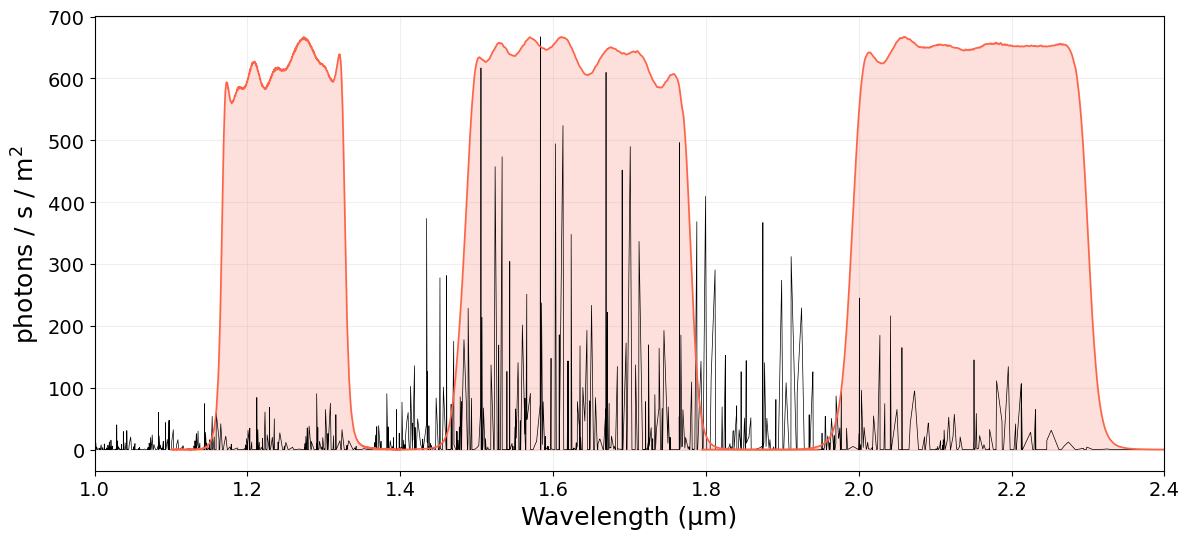

In [129]:
plt.figure(figsize=(12, 5.5))

# Main OH spectrum
plt.plot(
    normalised_spectrum[:, 0],
    normalised_spectrum[:, 1],
    label="Normalised Spectrum",
    linewidth=0.5,
    color="k"
)

spectrum_peak = np.max(normalised_spectrum[:, 1])

# -------------------------
# J filter
# -------------------------
J_wave = J_filter[:, 0] * 1e-4
J_trans_scaled = J_filter[:, 1] / np.max(J_filter[:, 1]) * spectrum_peak

plt.fill_between(
    J_wave,
    0,
    J_trans_scaled,
    color="salmon",
    alpha=0.25
)

plt.plot(
    J_wave,
    J_trans_scaled,
    color="tomato",
    linewidth=1.2,
    label="J band"
)

# -------------------------
# H filter
# -------------------------
H_wave = H_filter[:, 0] * 1e-4
H_trans_scaled = H_filter[:, 1] / np.max(H_filter[:, 1]) * spectrum_peak

plt.fill_between(
    H_wave,
    0,
    H_trans_scaled,
    color="salmon",
    alpha=0.25
)

plt.plot(
    H_wave,
    H_trans_scaled,
    color="tomato",
    linewidth=1.2,
    label="H band"
)

# -------------------------
# K filter
# -------------------------
K_wave = K_filter_test_short[:, 0]
K_trans_scaled = (
    K_filter_test_short[:, 1]
    / np.max(K_filter_test_short[:, 1])
    * spectrum_peak
)

plt.fill_between(
    K_wave,
    0,
    K_trans_scaled,
    color="salmon",
    alpha=0.25
)

plt.plot(
    K_wave,
    K_trans_scaled,
    color="tomato",
    linewidth=1.2,
    label="K band"
)

# Axis limits
plt.xlim(1.0, 2.4)

# Axis labels and ticks
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Wavelength (µm)", fontsize=18)
plt.ylabel("photons / s / m$^2$", fontsize=18)

plt.grid(alpha=0.2)
# plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [85]:
from pathlib import Path

data_dir = Path("/Users/tliu/oh_suppression/data")

for f in data_dir.iterdir():
    if "rose" in f.name.lower():
        print(f)

/Users/tliu/oh_suppression/data/rosed.dat
/Users/tliu/oh_suppression/data/rosed2_bin10.dat


In [86]:
file_path = "/Users/tliu/oh_suppression/data/rosed.dat"

with open(file_path, "r", encoding="utf-8", errors="replace") as f:
    for i in range(20):
        print(repr(f.readline()))

'1\t0\n'
'10000001/10000000\t0\n'
'5000001/5000000\t0\n'
'10000003/10000000\t0\n'
'2500001/2500000\t0\n'
'2000001/2000000\t0\n'
'5000003/5000000\t0\n'
'10000007/10000000\t0\n'
'1250001/1250000\t0\n'
'10000009/10000000\t0\n'
'1000001/1000000\t0\n'
'10000011/10000000\t0\n'
'2500003/2500000\t0\n'
'10000013/10000000\t0\n'
'5000007/5000000\t0\n'
'2000003/2000000\t0\n'
'625001/625000\t0\n'
'10000017/10000000\t0\n'
'5000009/5000000\t0\n'
'10000019/10000000\t0\n'


In [87]:
import numpy as np

rosed = np.genfromtxt(
    "/Users/tliu/oh_suppression/data/rosed.dat",
    comments="#",
    invalid_raise=False
)

print(rosed.shape)
print(rosed[:5])

(10000001, 2)
[[ 1.  0.]
 [nan  0.]
 [nan  0.]
 [nan  0.]
 [nan  0.]]


In [88]:
rosed = np.genfromtxt(
    "/Users/tliu/oh_suppression/data/rosed.dat",
    skip_header=1,
    comments="#",
    invalid_raise=False
)

In [90]:
rosed

array([[           nan, 0.00000000e+00],
       [           nan, 0.00000000e+00],
       [           nan, 0.00000000e+00],
       ...,
       [           nan, 4.06478074e-08],
       [           nan, 4.09242414e-08],
       [2.00000000e+00, 4.12035266e-08]], shape=(10000000, 2))

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

file_path = Path("/Users/tliu/oh_suppression/data/rosed.dat")

rose_intensity = np.loadtxt(file_path, usecols=1)

rose_wavelength = np.linspace(1.0, 2.0, rose_intensity.size)

print(rose_wavelength.shape)
print(rose_intensity.shape)
print(rose_wavelength[:5])
print(rose_intensity[:5])
print(rose_wavelength[-5:])
print(rose_intensity[-5:])

(10000001,)
(10000001,)
[1.        1.0000001 1.0000002 1.0000003 1.0000004]
[0. 0. 0. 0. 0.]
[1.9999996 1.9999997 1.9999998 1.9999999 2.       ]
[4.01033376e-08 4.03741856e-08 4.06478074e-08 4.09242414e-08
 4.12035266e-08]


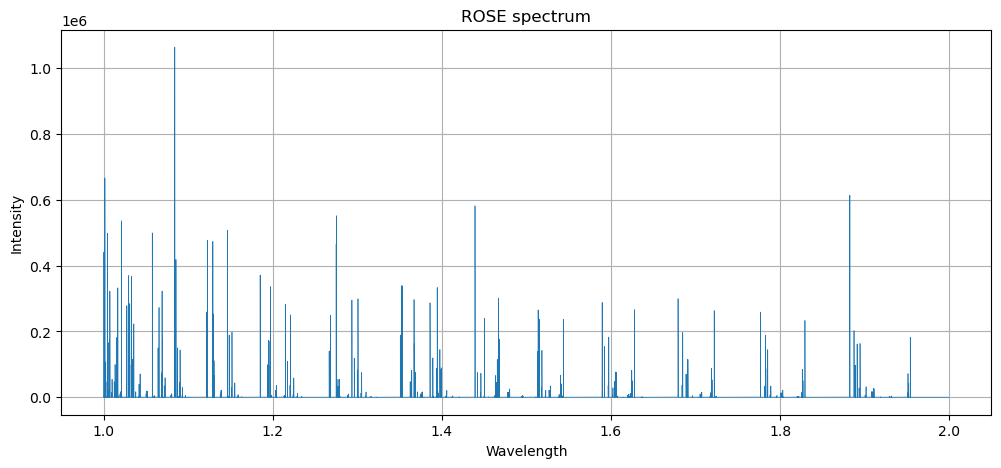

In [95]:
plt.figure(figsize=(12, 5))
plt.plot(rose_wavelength, rose_intensity, linewidth=0.5)
plt.xlabel("Wavelength")
plt.ylabel("Intensity")
plt.title("ROSE spectrum")
plt.grid()
plt.show()

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

data_dir = Path("/Users/tliu/oh_suppression/data")

rose_file = data_dir / "rosed.dat"
rose_bin_file = data_dir / "rosed2_bin10.dat"
rousselot_file = data_dir / "Rousellot_list_v2.0.dat"

In [97]:
rose_intensity = np.loadtxt(rose_file, usecols=1)
rose_wavelength = np.linspace(1.0, 2.0, rose_intensity.size)

print("rosed.dat")
print("wavelength:", rose_wavelength.shape)
print("intensity:", rose_intensity.shape)
print(rose_wavelength[:5], rose_intensity[:5])
print(rose_wavelength[-5:], rose_intensity[-5:])

rosed.dat
wavelength: (10000001,)
intensity: (10000001,)
[1.        1.0000001 1.0000002 1.0000003 1.0000004] [0. 0. 0. 0. 0.]
[1.9999996 1.9999997 1.9999998 1.9999999 2.       ] [4.01033376e-08 4.03741856e-08 4.06478074e-08 4.09242414e-08
 4.12035266e-08]


In [98]:
with open(rose_bin_file, "r", encoding="utf-8", errors="replace") as f:
    for i in range(10):
        print(repr(f.readline()))

'1.0000004\t0.\n'
'1.00000135\t0.\n'
'1.00000235\t0.\n'
'1.00000335\t0.\n'
'1.0000043499999998\t0.\n'
'1.00000535\t0.\n'
'1.00000635\t0.\n'
'1.00000735\t0.\n'
'1.0000083499999999\t0.\n'
'1.0000093499999998\t0.\n'


In [100]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

data_dir = Path("/Users/tliu/oh_suppression/data")

rose_bin_file = data_dir / "rosed2_bin10.dat"

rose_bin = np.loadtxt(rose_bin_file)

rose_bin_wavelength = rose_bin[:, 0]
rose_bin_intensity = rose_bin[:, 1]

print(rose_bin.shape)
print(rose_bin[:5])

(1000001, 2)
[[1.0000004  0.        ]
 [1.00000135 0.        ]
 [1.00000235 0.        ]
 [1.00000335 0.        ]
 [1.00000435 0.        ]]


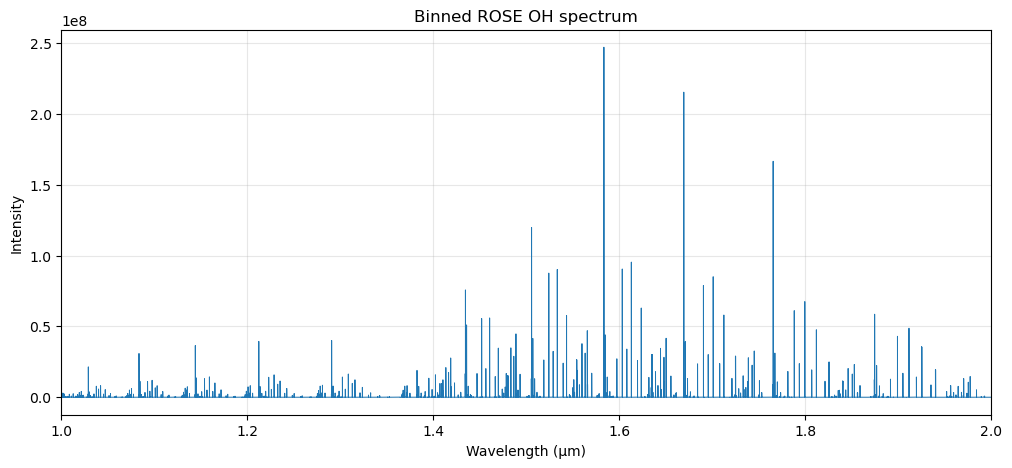

In [101]:
plt.figure(figsize=(12, 5))
plt.plot(rose_bin_wavelength, rose_bin_intensity, linewidth=0.7)
plt.xlabel("Wavelength (µm)")
plt.ylabel("Intensity")
plt.title("Binned ROSE OH spectrum")
plt.xlim(1.0, 2.0)
plt.grid(alpha=0.3)
plt.show()

In [102]:
with open(rousselot_file, "r", encoding="utf-8", errors="replace") as f:
    for i in range(20):
        print(repr(f.readline()))

'0.613824 1258\n'
'0.613827 1258\n'
'0.613847 3361\n'
'0.61385 3361\n'
'0.613931 648.3\n'
'0.613936 648.3\n'
'0.614056 345.7\n'
'0.614056 345.7\n'
'0.614067 1545\n'
'0.61407 1545\n'
'0.614089 195\n'
'0.614094 195\n'
'0.614115 6512\n'
'0.614118 6512\n'
'0.614507 2726\n'
'0.614508 2726\n'
'0.614535 45.21\n'
'0.614539 45.21\n'
'0.614547 74.66\n'
'0.614549 74.66\n'


In [104]:
rousselot = np.genfromtxt(
    rousselot_file,
    comments="#",
    invalid_raise=False
)

print("Rousselot shape:", rousselot.shape)
print(rousselot[:5])

Rousselot shape: (4732, 2)
[[6.13824e-01 1.25800e+03]
 [6.13827e-01 1.25800e+03]
 [6.13847e-01 3.36100e+03]
 [6.13850e-01 3.36100e+03]
 [6.13931e-01 6.48300e+02]]


In [105]:
rousselot_wavelength = rousselot[:, 0]
rousselot_intensity = rousselot[:, 1]

In [106]:
if np.nanmedian(rousselot_wavelength) > 100:
    rousselot_wavelength_um = rousselot_wavelength / 1e4
else:
    rousselot_wavelength_um = rousselot_wavelength

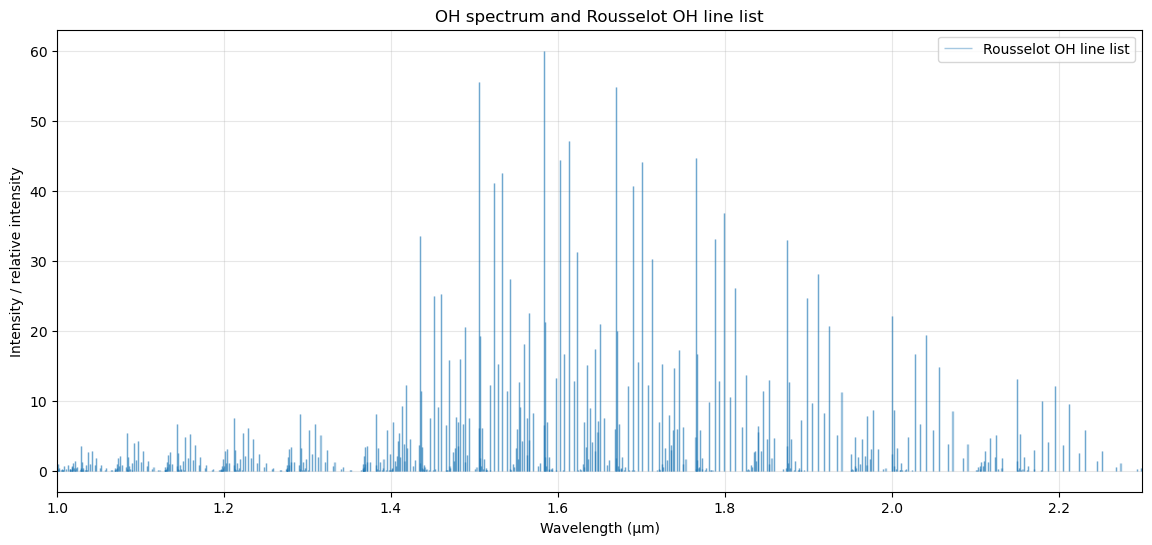

In [119]:
step = 1000

plt.figure(figsize=(14, 6))

# plt.plot(
#     rose_wavelength[::step],
#     rose_intensity[::step],
#     linewidth=0.6,
#     label="rosed.dat, downsampled"
# )

# plt.plot(
#     rose_bin_wavelength,
#     rose_bin_intensity,
#     linewidth=0.8,
#     label="rosed2_bin10.dat"
# )

plt.vlines(
    rousselot_wavelength_um,
    ymin=0,
    ymax=rousselot_intensity / np.nanmean(rousselot_intensity),
    alpha=0.4,
    linewidth=1,
    label="Rousselot OH line list"
)

plt.xlabel("Wavelength (µm)")
plt.ylabel("Intensity / relative intensity")
plt.title("OH spectrum and Rousselot OH line list")
plt.xlim(1.0, 2.3)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

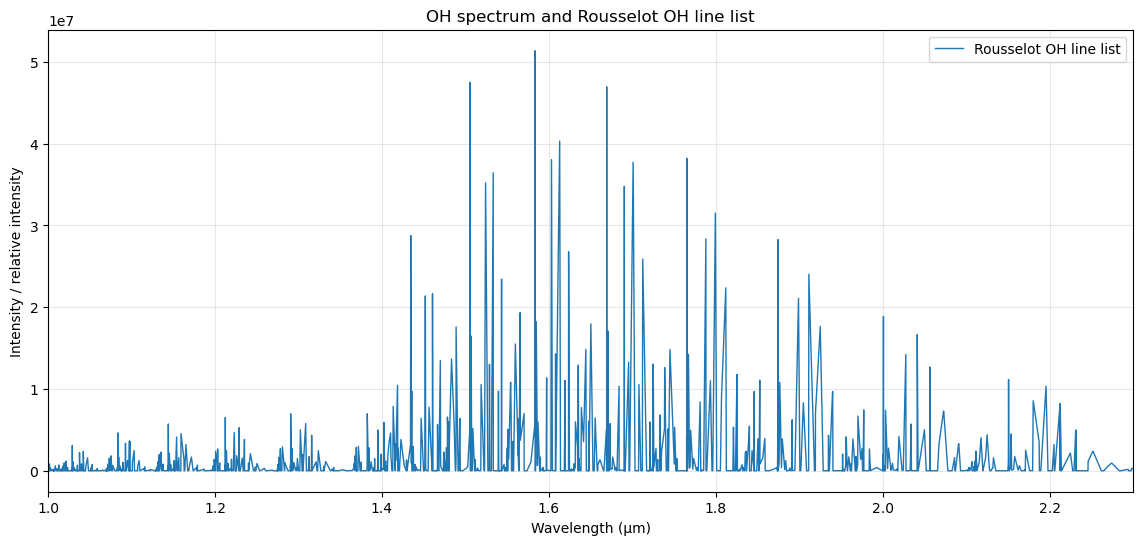

In [121]:
plt.figure(figsize=(14, 6))
plt.plot(rousselot_wavelength_um,rousselot_intensity,
    linewidth=1,
    label="Rousselot OH line list"
)

plt.xlabel("Wavelength (µm)")
plt.ylabel("Intensity / relative intensity")
plt.title("OH spectrum and Rousselot OH line list")
plt.xlim(1.0, 2.3)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [122]:
np.shape(rousselot_wavelength_um)

(4732,)